 # Extrapolate RSSE from tiled smaller to larger structure

In [25]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
#import matplotlib.tri as tri
import sisl as si
import os
from tqdm.auto import tqdm
import time
from scipy.spatial import cKDTree
from scipy.linalg import block_diag
from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from MyTools import *

### Setup Armchair graphene lattice
we choose this setup to avoid zig-zag edge states

In [27]:

a_cc = 1.42
sq3 = np.sqrt(3.0)
# 6-atom graphene cell (one hexagon)
xyz = [[a_cc*np.cos(t),a_cc*np.sin(t),20.] for t in 2.*np.pi*np.arange(0,6)/6]
# Lattice vectors
cell = np.array([
    [3.0 * a_cc,              0.0,           0.0],
    [1.5 * a_cc,   1.5 * sq3 * a_cc,         0.0],
    [0.0,                     0.0,          20.0],  # vacuum
])
graphene6 = si.Geometry(
    xyz,
    atoms=si.Atom("C"),
    lattice=si.Lattice(cell)
)
graphene6.set_nsc([3,3,1])

### set up electrode structure and TB hamiltonian

In [28]:

g_elecL = graphene6.copy() ## Use block expansion 
H_elecL = si.Hamiltonian(g_elecL)
r = (0.1, 1.44)
t = (0.0, -2.7)
H_elecL.construct([r,t])

### Repetitions and Real-space Self-energy

In [29]:
N1 = 4; N2 = 6;
RSSE1 = si.RealSpaceSE(H_elecL, semi_axis=0, k_axes=1, unfold=(N1, N1, 1))
RSSE2 = si.RealSpaceSE(H_elecL, 0, 1, (N2, N2, 1))
H_rs_elec1, rs_elec_indices1 = RSSE1.real_space_coupling(ret_indices=True)
H_rs_elec2, rs_elec_indices2 = RSSE2.real_space_coupling(ret_indices=True)

g1 = H_elecL.geometry.tile(N1,0).tile(N1,1) ## Full geometry: small
g2 = H_elecL.geometry.tile(N2,0).tile(N2,1) ## Fulle geometry: larger
g1e = g1.sub(rs_elec_indices1)  ## connecting/frame/edge geometries
g2e = g2.sub(rs_elec_indices2)
g1e.move(-g1e.center())
g1e.move(-g1e.center())

<sisl.Geometry na=30, no=30, nsc=[3 3 1]>

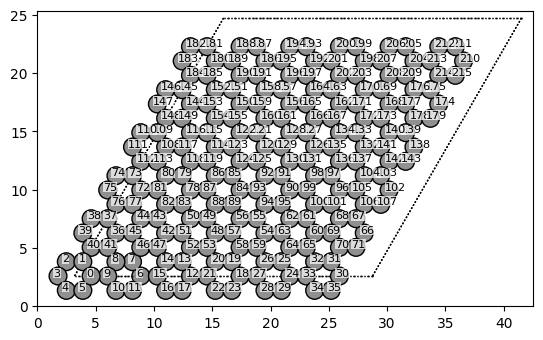

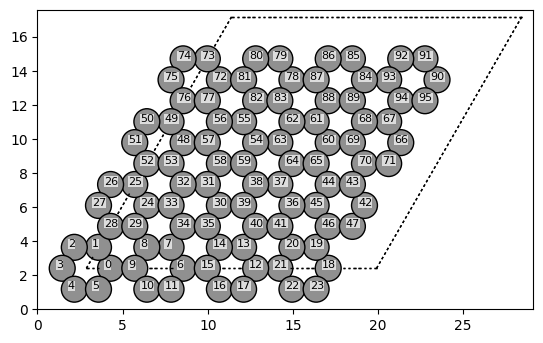

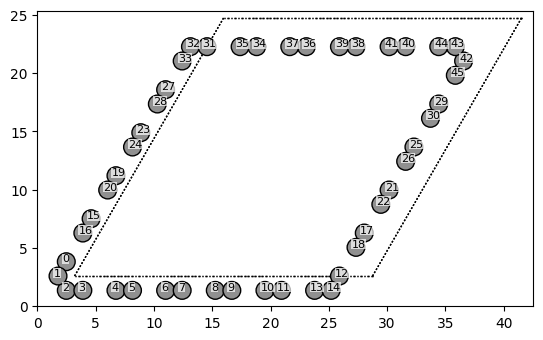

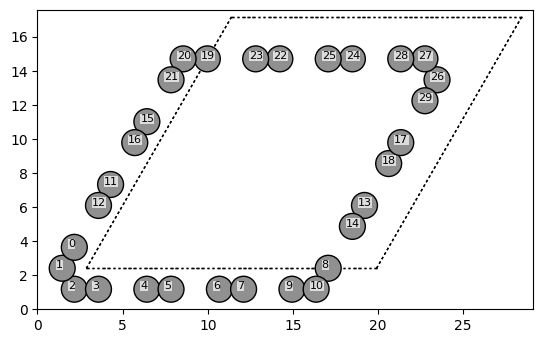

In [30]:
plot_with_numbers(g2);plot_with_numbers(g1)
plot_with_numbers(g2e);plot_with_numbers(g1e)

In [31]:
## Fractional coordinates:
fc1 = np.array([np.round(g1e.rcell@r/(2.*np.pi),3) for r in g1e.xyz])
fc2 = np.array([np.round(g2e.rcell@r/(2.*np.pi),3) for r in g2e.xyz])

# Task: 
1) Identify the corner points(CP) for both g1e, g2e (CP)= TL,TR,BL,BR defined by the extreme projections of fractional atomic coordinates along a0, a1 of the atomic positions (note there may not be an actual atom there). 

2) **"Corner matching"**: We define a radius around the corner points given by R in units of min(cell vector lengths a0, a1) e.g. with default 1/4 of the sidelength of g1e or smaller. 
Now match the corner atoms within R around  each of the corner points of g2e with the corresponding in g1e such that the atoms sit in exactly the same relative position wrt the corner points in g1e and g2e. Calculate the distances to each corner points [d0,d1,d2,d3] for each atom in g1e, g2e.

3) **"Side matching"**: For the remaining atoms (those ouside the corner circles): Identify which of the 4 lines (BL to BR, BR to TR, TR to TL, TL to BL) an atom belongs to by comparing its distance to the corner points: (e.g. the right-most edge should contain points where the distance to the right-corner points BR,TR are the smallest compared to the other distances).

4) Now we have classified each atom by a corner point (CP: BL,BR,TR,TL) or to a Side (BLBR, BRTR, TRTL, TLBL). We will match the edge atoms -- do something smart which will keep the sequence (distance to corners) and the distance vectors to neighbors so for graphene the A,B-type atoms are conserved going between the structures.




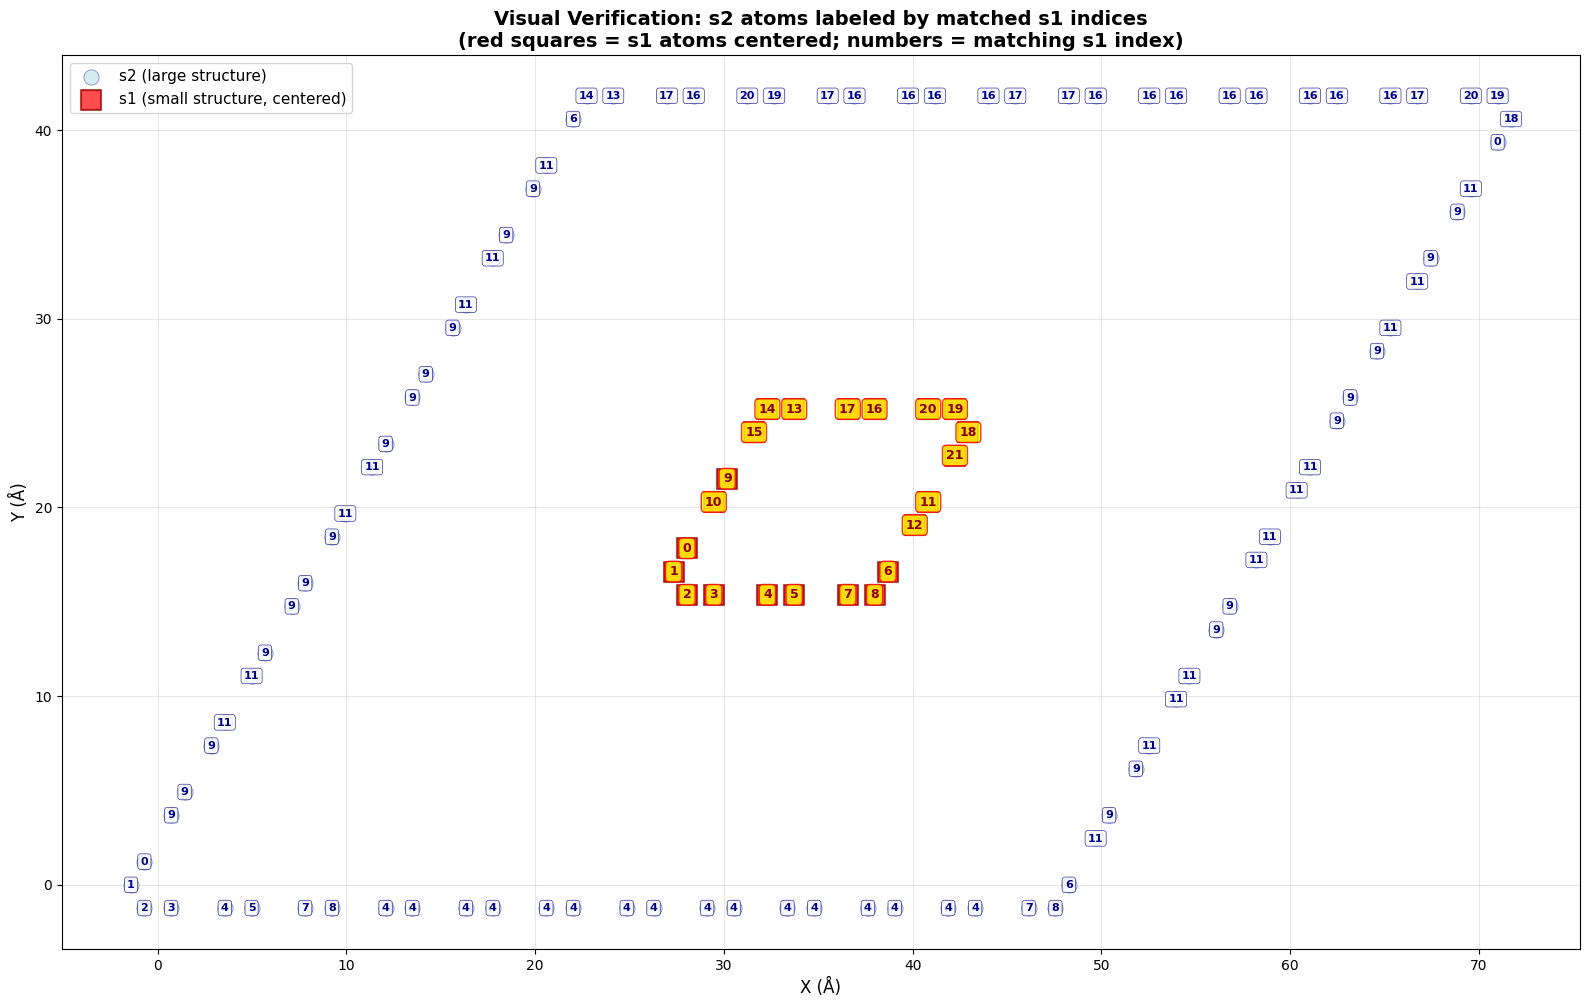

### Example code not working..

In [32]:
from scipy.spatial import cKDTree
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

def find_most_similar_atoms(struct1, struct2, unique=False, return_distances=False):
    """Pair each atom in struct1 with the most similar (nearest) position in struct2.

    Arguments:
      struct1, struct2 : sisl.Geometry-like or (N,3) numpy arrays of coordinates
      unique : bool -- if True, enforce one-to-one matching with Hungarian algorithm
      return_distances : bool -- if True, also return distances array

    Returns:
      pairs : list of (i_struct1, i_struct2)
      distances (optional): np.ndarray of distances for each pair
    """
    def to_xyz(s):
        if hasattr(s, 'xyz'):
            return np.asarray(s.xyz, dtype=float)
        a = np.asarray(s, dtype=float)
        if a.ndim == 2 and a.shape[1] == 3:
            return a
        raise ValueError('struct1/struct2 should provide .xyz or be Nx3 array')

    xyz1 = to_xyz(struct1)
    xyz2 = to_xyz(struct2)
    n1 = len(xyz1)
    n2 = len(xyz2)
    if n1 == 0 or n2 == 0:
        raise ValueError('struct1 and struct2 must contain atoms')

    if unique:
        # minimize total distance with one-to-one matching (n1<=n2 preferred)
        if n1 > n2:
            raise ValueError('unique=True requires len(struct1)<=len(struct2)')
        cost = cdist(xyz1, xyz2, metric='euclidean')
        row_idx, col_idx = linear_sum_assignment(cost)
        # linear_sum_assignment returns min(n1,n2) assignments
        if len(row_idx) != n1:
            # if equal sizes this is expected; for n1<n2 it still returns n1
            pass
        pairs = list(zip(row_idx.tolist(), col_idx.tolist()))
        distances = cost[row_idx, col_idx]

    else:
        tree = cKDTree(xyz2)
        distances, nearest = tree.query(xyz1, k=1)
        pairs = [(i, int(j)) for i, j in enumerate(nearest)]

    if return_distances:
        return pairs, np.asarray(distances, dtype=float)
    else:
        return pairs

# Example usage:
#   pairs = find_most_similar_atoms(s1, s2)
#   for i1, i2 in pairs:
#       print(i1, i2, s1.xyz[i1], s2.xyz[i2])

In [33]:
# find_most_similar_atom_environment(g1e,g2e)
find_most_similar_atoms(g1e,g2e)

[(0, 0),
 (1, 1),
 (2, 2),
 (3, 3),
 (4, 4),
 (5, 5),
 (6, 6),
 (7, 7),
 (8, 9),
 (9, 8),
 (10, 9),
 (11, 15),
 (12, 16),
 (13, 10),
 (14, 10),
 (15, 19),
 (16, 20),
 (17, 17),
 (18, 18),
 (19, 23),
 (20, 23),
 (21, 24),
 (22, 28),
 (23, 28),
 (24, 34),
 (25, 35),
 (26, 21),
 (27, 36),
 (28, 37),
 (29, 22)]

NameError: name 's2_to_s1' is not defined

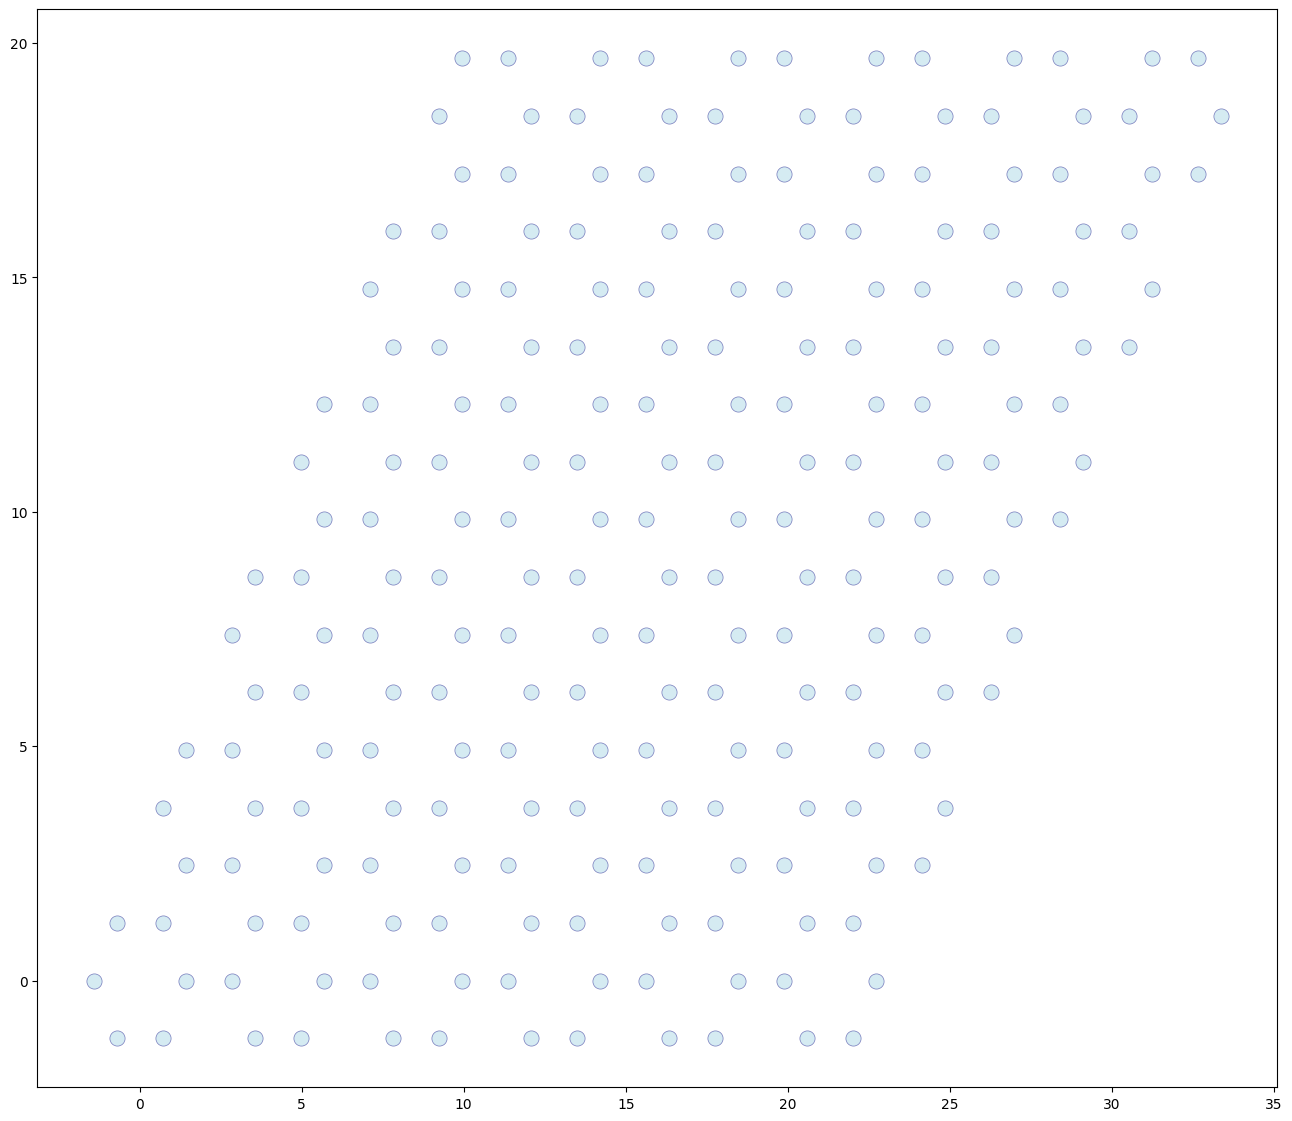

In [35]:
# Visual check: s2 atoms labeled by their matched s1 indices, with s1 overlaid in center
# s1_xyz = np.asarray(s1.xyz)
# s2_xyz = np.asarray(s2.xyz)
s1_xyz = np.asarray(g1.xyz)
s2_xyz = np.asarray(g2.xyz)

# Find centers
s1_center = s1_xyz.mean(axis=0)[:2]
s2_center = s2_xyz.mean(axis=0)[:2]

# Shift s1 to center of s2
shift_to_center = s2_center - s1_center
s1_xyz_centered = s1_xyz.copy()
s1_xyz_centered[:, :2] += shift_to_center

fig, ax = plt.subplots(figsize=(16, 14))

# Plot s2 atoms as base (light background)
ax.scatter(s2_xyz[:, 0], s2_xyz[:, 1], s=120, alpha=0.5, c='lightblue', 
          edgecolors='navy', linewidth=0.5, label='s2 (large structure)', zorder=1)

# Label each s2 atom with its matched s1 index
for i2 in range(len(s2_xyz)):
    i1_matched = s2_to_s1.get(i2, '?')
    ax.text(s2_xyz[i2, 0], s2_xyz[i2, 1], str(i1_matched), fontsize=8,
            ha='center', va='center', color='darkblue', weight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8, edgecolor='navy', linewidth=0.5),
            zorder=3)

# Overlay s1 in the center with distinctive markers
ax.scatter(s1_xyz_centered[:, 0], s1_xyz_centered[:, 1], s=200, alpha=0.7, c='red', 
          edgecolors='darkred', linewidth=1.5, label='s1 (small structure, centered)', 
          marker='s', zorder=2)

# Label s1 atoms with their own indices
for i1 in range(len(s1_xyz_centered)):
    ax.text(s1_xyz_centered[i1, 0], s1_xyz_centered[i1, 1], str(i1), fontsize=9,
            ha='center', va='center', color='darkred', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8, edgecolor='red', linewidth=1.0),
            zorder=4)

ax.set_title('Visual Verification: s2 atoms labeled by matched s1 indices\n(red squares = s1 atoms centered; numbers = matching s1 index)', 
            fontsize=14, weight='bold')
ax.set_xlabel('X (Å)', fontsize=12)
ax.set_ylabel('Y (Å)', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Analysis of sigmas.. for later..
For the exact result we should have a PDOS which is like the bulk. For the extrapolated we seek approximations to go large reasonable good when we move away from the edge.

In [36]:
def plot_sigma_xy(e,size_scale=300,cmap='RdBu_r',onsite=True):
    tmp = stbtse.self_energy(elec=0,E=e,sort=True).data
    pvt = stbtse.pivot(elec=0, in_device=True, sort=True).reshape(-1, 1)  # and downfolded to smaller region
    no_d = stbtse.no_d ## down-folded region size
    #print(tmp[0].dtype)
    ZeroMat = 0.*1j*np.eye(no_d)
    Sigma = ZeroMat.copy()  # transform to original orbit
    Sigma[pvt, pvt.T] += tmp
    xyz = Htot.geometry.xyz
    idx_dev = stbtse.a_dev
    xyz_dev = xyz[idx_dev]
    # Normalize for visualization
    if onsite:
        val = np.diag(Sigma)  #onsite
    else:
        val = np.sum(Sigma,axis=0)
    val_abs = np.abs(val)
    val_norm = val_abs / np.max(val_abs) if np.max(val_abs) > 0 else val_abs
    val_imag = val.imag
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 8))
    scatterall = ax.scatter(xyz.T[0],xyz.T[1], s=5, marker='x', c='black')
    # Plot circles
    x,y = xyz_dev.T[0:2]
    #return len(x),len(sigma_norm)
    scatter = ax.scatter(x,y, s=val_norm * size_scale, c=val_imag, 
                         cmap=cmap, alpha=0.7, edgecolors='black', linewidth=0.5)
    scatteralldev = ax.scatter(x,y, s=10, c='black')
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Im(σ)', rotation=270, labelpad=20)
    
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Imaginary part of σ matrix')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    return fig, ax